# Train — ResNet-18

Trains and evaluates ResNet-18 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet18"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1814 | Val: 441 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet18"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-18: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders, same as every other architecture
# here -- its own (capped) batch size and image size, per cfg.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-18: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model (Transfer Learning with ResNet-18)

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-18)
# ---------------------------------------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the tuned step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-18] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ResNet-18] Epoch   1/100 | LR: 1.00e-04 | train loss 0.9768 acc 0.601 | val loss 0.7350 acc 0.714 *


[ResNet-18] Epoch   2/100 | LR: 1.00e-04 | train loss 0.5902 acc 0.743 | val loss 0.4660 acc 0.791 *


[ResNet-18] Epoch   3/100 | LR: 1.00e-04 | train loss 0.4669 acc 0.794 | val loss 0.4347 acc 0.828 *


[ResNet-18] Epoch   4/100 | LR: 1.00e-04 | train loss 0.4241 acc 0.813 | val loss 0.4827 acc 0.812


...

[ResNet-18] Epoch  15/100 | LR: 1.00e-05 | train loss 0.1599 acc 0.923 | val loss 0.4406 acc 0.871


[ResNet-18] Epoch  16/100 | LR: 1.00e-05 | train loss 0.1357 acc 0.932 | val loss 0.4116 acc 0.878


[ResNet-18] Epoch  17/100 | LR: 1.00e-05 | train loss 0.0892 acc 0.960 | val loss 0.3940 acc 0.878


[ResNet-18] Epoch  18/100 | LR: 1.00e-05 | train loss 0.0745 acc 0.962 | val loss 0.3941 acc 0.882


[ResNet-18] Epoch  19/100 | LR: 1.00e-05 | train loss 0.0852 acc 0.961 | val loss 0.4158 acc 0.862

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 19.

[ResNet-18] Restored best checkpoint (val loss = 0.3417)


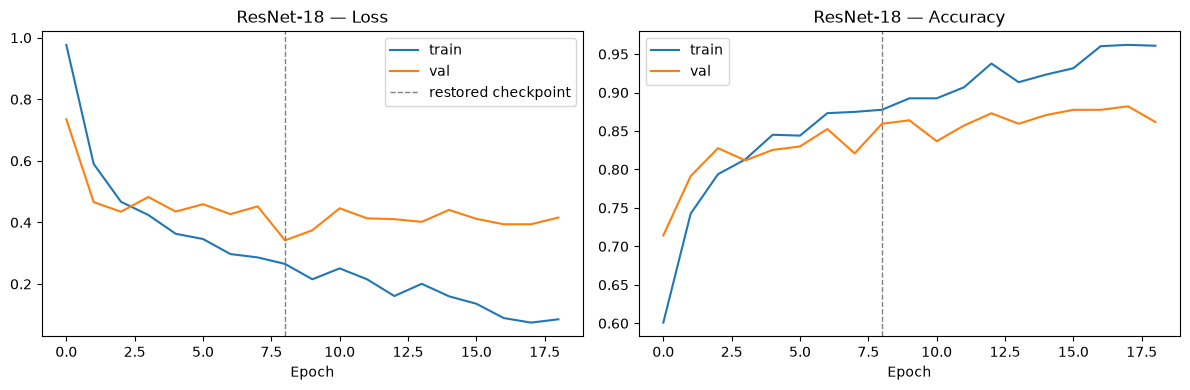

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.754


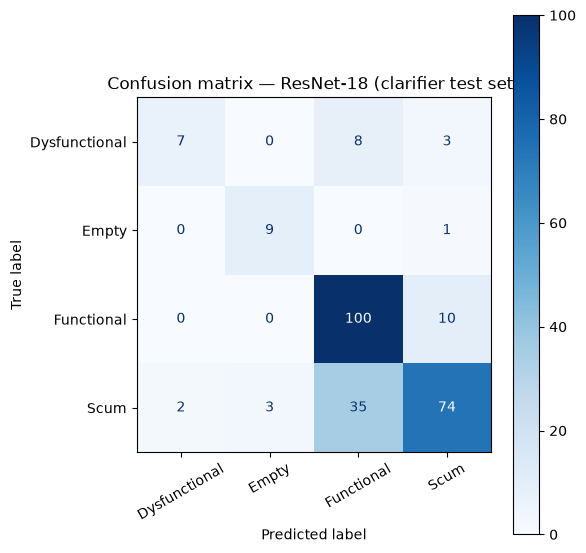

               precision    recall  f1-score   support

Dysfunctional      0.778     0.389     0.519        18
        Empty      0.750     0.900     0.818        10
   Functional      0.699     0.909     0.791       110
         Scum      0.841     0.649     0.733       114

     accuracy                          0.754       252
    macro avg      0.767     0.712     0.715       252
 weighted avg      0.771     0.754     0.746       252



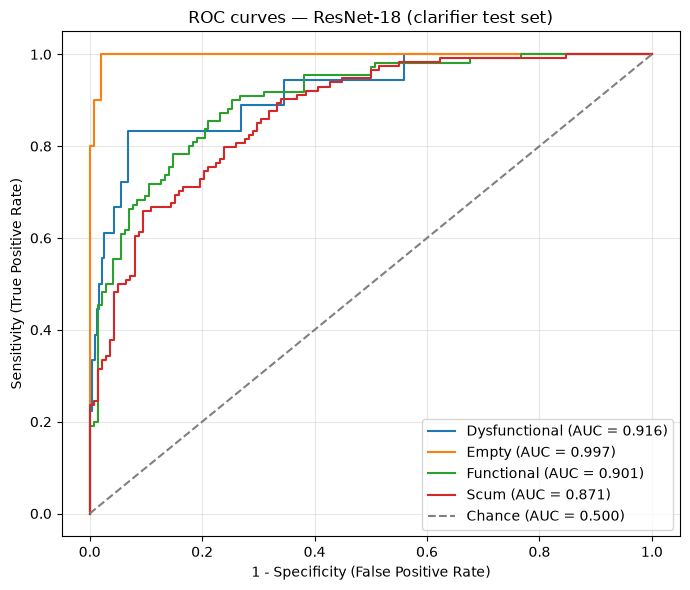

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.916
  Empty          : 0.997
  Functional     : 0.901
  Scum           : 0.871

Mean AUC (over 4/4 classes with test examples): 0.921


(np.float64(0.753968253968254),
 {'Dysfunctional': 0.9164292497625831,
  'Empty': 0.9971074380165289,
  'Functional': 0.9007682458386684,
  'Scum': 0.8706458174421561})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-18", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [6]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/results_clarifier_resnet18_Fisantekraal.pkl


Saved model weights to ../models/clarifier_resnet18_cnn.pt
